# Arbitrage-Free Vol Surface & Flow Hedging Optimizer

**Prerequisite:** Build the C++ engine first (`cd cpp && python setup.py build_ext --inplace`).

1. C++ Engine Smoke Tests
2. Yield Curve from FRED
3. Option Chain (yfinance)
4. Dividend Projection, Implied Dividends & Forward Curve
5. SSVI Surface Calibration + Arb Detection
6. Greeks Computation
7. Risk Ladder (2D Full Revaluation)
8. Hedging Efficient Frontier
9. ETF Premium / Discount Analysis
10. ML Warm-Start (Synthetic Demo) with Timing Comparison

In [1]:
import sys, os, time
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# Load .env file if present
try:
    from dotenv import load_dotenv
    load_dotenv(os.path.join('..', '.env'))
except ImportError:
    pass

FRED_API_KEY = os.environ.get('FRED_API_KEY')
if not FRED_API_KEY:
    raise RuntimeError('FRED_API_KEY not set. Add it to .env or export it.')

TICKER = 'SPY'

import qr_engine
print('qr_engine loaded:', dir(qr_engine))

from qr_engine.ssvi import total_variance, surface_vec, derivatives as ssvi_derivs
from qr_engine.greeks import bs_price, bs_implied_vol, compute as greeks_compute

qr_engine loaded: ['__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'greeks', 'ssvi']


## 1. C++ Engine Smoke Tests

In [2]:
# SSVI
theta, rho, eta = 0.04, -0.25, 1.0
k_test = 0.0
w = total_variance(k_test, theta, rho, eta)
print('SSVI total_variance(k=%.2f, theta=%.2f, rho=%.2f, eta=%.1f) = %.6f' % (k_test, theta, rho, eta, w))

d = ssvi_derivs(k_test, theta, rho, eta)
print('SSVI derivatives: w=%.6f, dw/dk=%.6f, d2w/dk2=%.6f, dw/dtheta=%.6f'
      % (d.w, d.dw_dk, d.d2w_dk2, d.dw_dtheta))

k_vec = np.linspace(-0.3, 0.3, 7).tolist()
w_vec = surface_vec(k_vec, theta, rho, eta)
print('surface_vec over 7 strikes: min=%.6f, max=%.6f' % (min(w_vec), max(w_vec)))

# Greeks
F, K, T, r, sigma = 585.0, 590.0, 0.25, 0.045, 0.18
call_px = bs_price(F, K, T, r, sigma, True)
put_px = bs_price(F, K, T, r, sigma, False)
print('BS call(F=%.0f, K=%.0f, T=%.2f, sigma=%.0f%%) = $%.4f' % (F, K, T, sigma * 100, call_px))
print('BS put = $%.4f' % put_px)
print('Put-call parity check: C - P = %.4f, (F-K)*df = %.4f'
      % (call_px - put_px, (F - K) * np.exp(-r * T)))

iv_back = bs_implied_vol(call_px, F, K, T, r, True)
print('Implied vol round-trip: input=%.4f, recovered=%.4f, diff=%.2e'
      % (sigma, iv_back, abs(sigma - iv_back)))

g = greeks_compute(F, K, T, r, sigma, True)
print('Greeks: delta=%.4f, gamma=%.6f, vega=%.4f, theta=%.4f, vanna=%.6f, volga=%.4f'
      % (g.delta, g.gamma, g.vega, g.theta, g.vanna, g.volga))

SSVI total_variance(k=0.00, theta=0.04, rho=-0.25, eta=1.0) = 0.040000
SSVI derivatives: w=0.040000, dw/dk=-0.050000, d2w/dk2=0.468750, dw/dtheta=0.500000
surface_vec over 7 strikes: min=0.037500, max=0.067500
BS call(F=585, K=590, T=0.25, sigma=18%) = $18.4721
BS put = $23.4162
Put-call parity check: C - P = -4.9441, (F-K)*df = -4.9441
Implied vol round-trip: input=0.1800, recovered=0.1800, diff=1.94e-16
Greeks: delta=0.4749, gamma=0.007481, vega=115.2431, theta=40.7750, vanna=0.305474, volga=4.4331


## 2. Yield Curve from FRED

[LIVE] Fetched yield curve from FRED (as of 2026-02-26)
  T=0.25y -> r=3.647%, df=0.9909
  T=1.00y -> r=3.489%, df=0.9657
  T=5.00y -> r=3.539%, df=0.8378
  T=10.00y -> r=3.980%, df=0.6717


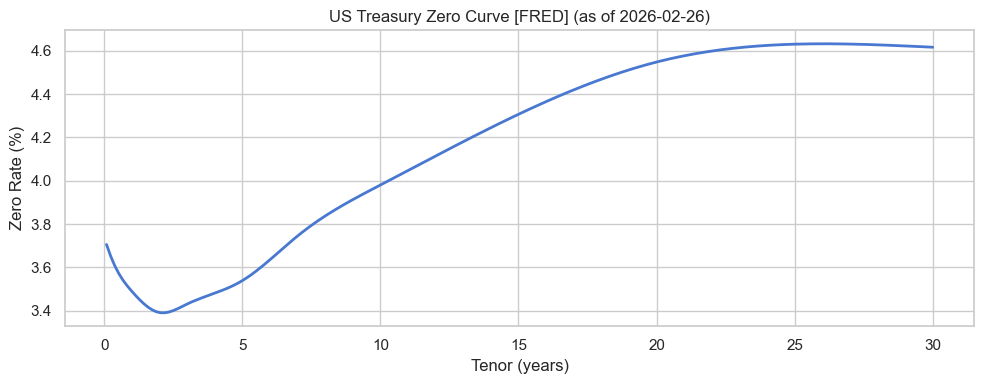

In [3]:
from python.data.fred_rates import fetch_yield_curve

curve = fetch_yield_curve(FRED_API_KEY)
print('[LIVE] Fetched yield curve from FRED (as of %s)' % curve.as_of_date)

for t, r_val in zip([0.25, 1.0, 5.0, 10.0], [curve.rate(x) for x in [0.25, 1.0, 5.0, 10.0]]):
    print('  T=%.2fy -> r=%.3f%%, df=%.4f' % (t, r_val * 100, curve.discount(t)))

fig, ax = plt.subplots(figsize=(10, 4))
fine_t = np.linspace(curve.tenors[0], curve.tenors[-1], 200)
fine_r = np.array([curve.rate(t) for t in fine_t])
ax.plot(fine_t, fine_r * 100, 'b-', linewidth=2)
ax.set_xlabel('Tenor (years)')
ax.set_ylabel('Zero Rate (%)')
ax.set_title('US Treasury Zero Curve [FRED] (as of %s)' % curve.as_of_date)
plt.tight_layout()
plt.show()

## 3. Option Chain (yfinance)

In [4]:
from python.data.options_chain import fetch_yfinance

chain = fetch_yfinance(TICKER)
spot = chain.spot
print('[LIVE] Fetched %d quotes across %d expiries for %s (spot=%.2f)'
      % (len(chain.quotes), len(chain.expiries()), TICKER, spot))

for exp in chain.expiries():
    n = len(chain.for_expiry(exp))
    T_exp = (exp - pd.Timestamp.now()).days / 365.25
    print('  %s (T=%.3fy): %d quotes' % (exp.date(), T_exp, n))

  [options_chain] Fetched 8951 quotes across 35 expiries for SPY (spot=685.99)
[LIVE] Fetched 8951 quotes across 35 expiries for SPY (spot=685.99)
  2026-03-02 (T=0.000y): 143 quotes
  2026-03-03 (T=0.003y): 141 quotes
  2026-03-04 (T=0.005y): 146 quotes
  2026-03-05 (T=0.008y): 145 quotes
  2026-03-06 (T=0.011y): 265 quotes
  2026-03-09 (T=0.019y): 153 quotes
  2026-03-10 (T=0.022y): 151 quotes
  2026-03-11 (T=0.025y): 120 quotes
  2026-03-12 (T=0.027y): 121 quotes
  2026-03-13 (T=0.030y): 272 quotes
  2026-03-20 (T=0.049y): 382 quotes
  2026-03-27 (T=0.068y): 271 quotes
  2026-03-31 (T=0.079y): 503 quotes
  2026-04-02 (T=0.085y): 180 quotes
  2026-04-10 (T=0.107y): 128 quotes
  2026-04-17 (T=0.126y): 340 quotes
  2026-04-30 (T=0.162y): 357 quotes
  2026-05-15 (T=0.203y): 270 quotes
  2026-05-29 (T=0.241y): 358 quotes
  2026-06-18 (T=0.296y): 267 quotes
  2026-06-30 (T=0.329y): 314 quotes
  2026-07-31 (T=0.413y): 271 quotes
  2026-08-21 (T=0.471y): 155 quotes
  2026-08-31 (T=0.498y): 

## 4. Dividend Projection, Implied Dividends & Forward Curve

Historical schedule projects ex-dates and average amounts. Put-call parity
provides a market-implied cross-check on total dividend PV per expiry.
We decompose the implied PV back into individual dividends at the historical
schedule dates, then blend the two sources.

In [5]:
from python.data.dividends import (
    fetch_dividends, project_from_history, extract_implied_dividends,
    decompose_implied_dividends, blend_dividends, build_forward_curve,
)

# 4a. Historical projection
hist_divs = fetch_dividends(TICKER, period='3y')
print('[LIVE] Fetched %d historical dividends for %s' % (len(hist_divs), TICKER))

projected_hist = project_from_history(hist_divs, horizon_years=1.5)
print('Projected %d future dividends (historical):' % len(projected_hist))
for d in projected_hist[:4]:
    print('  %s: $%.2f (%s)' % (d.ex_date.date(), d.amount, d.source))

# 4b. Market-implied dividends via put-call parity
implied_pvs = extract_implied_dividends(chain, curve)
print('\nImplied cumulative div PV per expiry:')
for exp in sorted(implied_pvs.keys()):
    print('  %s: PV=$%.4f' % (exp.date(), implied_pvs[exp]))

implied_divs = decompose_implied_dividends(implied_pvs, projected_hist, spot, curve)
print('\nDecomposed into %d implied dividends:' % len([d for d in implied_divs if d.source == 'implied']))
for d in [dd for dd in implied_divs if dd.source == 'implied'][:4]:
    print('  %s: $%.2f (%s)' % (d.ex_date.date(), d.amount, d.source))

# 4c. Blend: prefer market-implied where available
projected = blend_dividends(projected_hist, implied_divs, method='prefer_implied')
print('\nBlended dividend schedule (%d total):' % len(projected))
for d in projected[:6]:
    print('  %s: $%.2f (%s)' % (d.ex_date.date(), d.amount, d.source))

# 4d. Forward curve from blended dividends
forwards = build_forward_curve(spot, projected, curve, chain.expiries())
forwards_hist_only = build_forward_curve(spot, projected_hist, curve, chain.expiries())
print('\nForward curve (hist vs implied-adjusted):')
for exp in sorted(forwards.keys()):
    T_exp = (exp - pd.Timestamp.now()).days / 365.25
    print('  %s (T=%.3fy): F_hist=%.2f  F_implied=%.2f  diff=%.2f'
          % (exp.date(), T_exp, forwards_hist_only[exp], forwards[exp],
             forwards[exp] - forwards_hist_only[exp]))

  [dividends] Fetched 12 dividends for SPY over 3y
[LIVE] Fetched 12 historical dividends for SPY
Projected 6 future dividends (historical):
  2026-03-20: $1.82 (historical)
  2026-06-19: $1.82 (historical)
  2026-09-18: $1.82 (historical)
  2026-12-18: $1.82 (historical)

Implied cumulative div PV per expiry:
  2026-03-09: PV=$0.0000
  2026-03-10: PV=$0.0000
  2026-03-11: PV=$0.0000
  2026-03-12: PV=$0.0000
  2026-03-13: PV=$0.0000
  2026-03-20: PV=$0.7966
  2026-03-27: PV=$1.4610
  2026-03-31: PV=$1.6719
  2026-04-02: PV=$1.5787
  2026-04-10: PV=$1.6477
  2026-04-17: PV=$1.6542
  2026-04-30: PV=$1.7348
  2026-05-15: PV=$1.5955
  2026-05-29: PV=$1.5775
  2026-06-18: PV=$1.9864
  2026-06-30: PV=$2.7495
  2026-07-31: PV=$3.0495
  2026-08-21: PV=$2.9605
  2026-08-31: PV=$3.0490
  2026-09-18: PV=$3.0794
  2026-09-30: PV=$4.0510
  2026-12-18: PV=$4.9461
  2026-12-31: PV=$5.9189
  2027-01-15: PV=$5.8065
  2027-03-19: PV=$6.5112
  2027-06-17: PV=$7.9174
  2027-12-17: PV=$11.2904
  2028-01-21

## 5. SSVI Surface Calibration + Arb Detection

In [6]:
from python.models.surface import calibrate_surface

t0_classical = time.perf_counter()
surface = calibrate_surface(chain, forwards, curve)
t1_classical = time.perf_counter()
classical_time = t1_classical - t0_classical

print('Calibrated %d tenor slices in %.4f seconds' % (len(surface.params_by_tenor), classical_time))
print('  Timing breakdown: prep=%.4f s (%.0f%%), opt=%.4f s (%.0f%%)'
      % (surface._timing['prep_s'],
         surface._timing['prep_s'] / classical_time * 100,
         surface._timing['opt_s'],
         surface._timing['opt_s'] / classical_time * 100))
print('Global rho=%.4f, eta=%.4f' % (surface.global_rho, surface.global_eta))
print('Pre-correction arb violations:  %d' % len(surface.violations_pre))
print('Post-correction arb violations: %d' % len(surface.violations_post))

for T_cal in sorted(surface.params_by_tenor.keys()):
    p = surface.params_by_tenor[T_cal]
    print('  T=%.3fy: theta=%.4f, rho=%.4f, eta=%.4f' % (T_cal, p.theta, p.rho, p.eta))

if surface.violations_pre:
    print('\nSample violations (pre-correction):')
    for v in surface.violations_pre[:3]:
        print('  [%s] %s' % (v.violation_type, v.description))

  [surface] 45 arb violations pre-correction; re-fitting with global rho/eta.
Calibrated 30 tenor slices in 0.5095 seconds
  Timing breakdown: prep=0.1281 s (25%), opt=0.2727 s (54%)
Global rho=-0.2999, eta=0.4998
Pre-correction arb violations:  45
Post-correction arb violations: 45
  T=0.019y: theta=0.0008, rho=-0.2999, eta=0.4998
  T=0.022y: theta=0.0007, rho=-0.2999, eta=0.4998
  T=0.025y: theta=0.0010, rho=-0.2999, eta=0.4998
  T=0.027y: theta=0.0012, rho=-0.2999, eta=0.4998
  T=0.030y: theta=0.0013, rho=-0.2999, eta=0.4998
  T=0.049y: theta=0.0007, rho=-0.2999, eta=0.4998
  T=0.068y: theta=0.0032, rho=-0.2999, eta=0.4998
  T=0.079y: theta=0.0028, rho=-0.2999, eta=0.4998
  T=0.085y: theta=0.0038, rho=-0.2999, eta=0.4998
  T=0.107y: theta=0.0045, rho=-0.2999, eta=0.4998
  T=0.126y: theta=0.0038, rho=-0.2999, eta=0.4998
  T=0.162y: theta=0.0071, rho=-0.2999, eta=0.4998
  T=0.203y: theta=0.0090, rho=-0.2999, eta=0.4998
  T=0.241y: theta=0.0116, rho=-0.2999, eta=0.4998
  T=0.296y: thet

## 5b. Vol Surface Plots (2D & 3D)

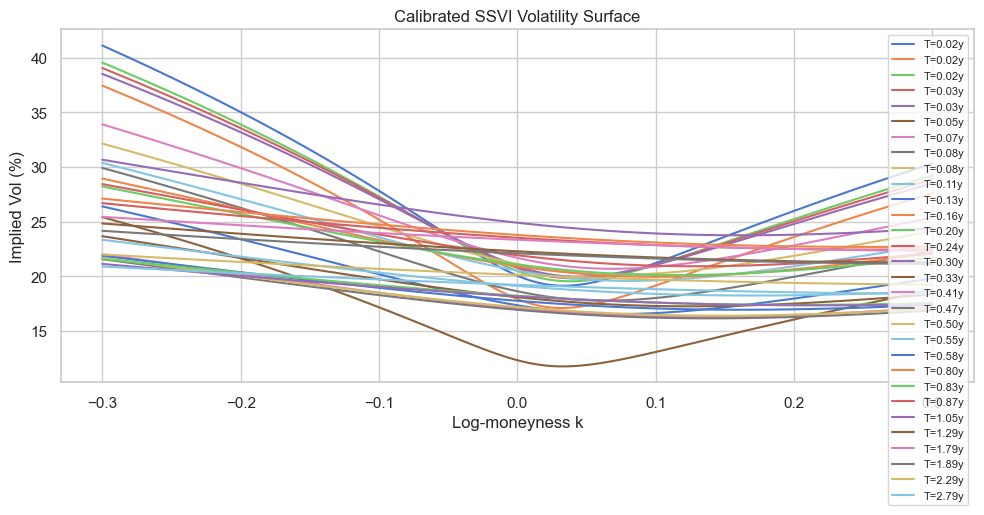

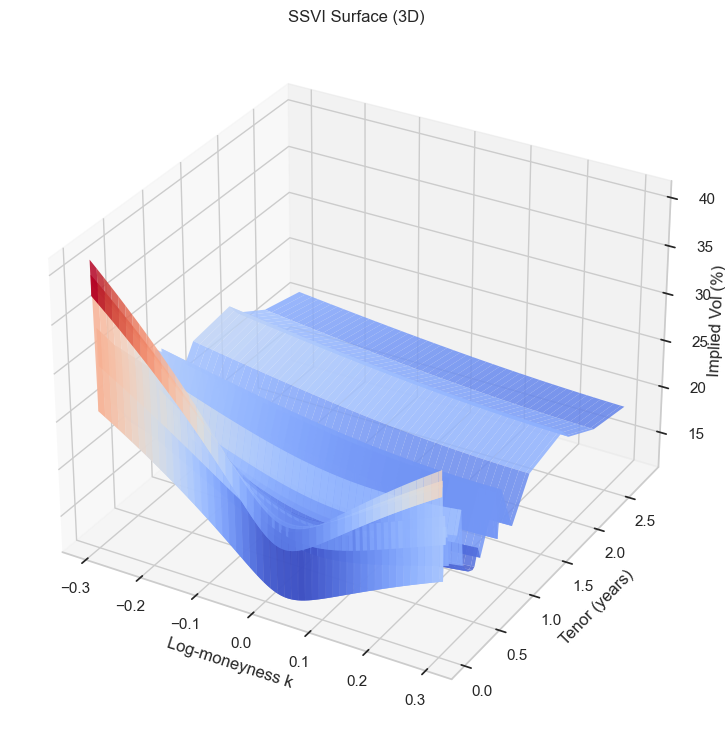

In [18]:
# 2D vol surface
k_grid = np.linspace(-0.3, 0.3, 100)
fig, ax = plt.subplots(figsize=(10, 5))
for T_cal in sorted(surface.params_by_tenor.keys()):
    ivs = [surface.implied_vol(k, T_cal) * 100 for k in k_grid]
    ax.plot(k_grid, ivs, label='T=%.2fy' % T_cal)
ax.set_xlabel('Log-moneyness k')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('Calibrated SSVI Volatility Surface')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 3D surface
tenor_grid = np.array(sorted(surface.params_by_tenor.keys()))
K_mesh, T_mesh = np.meshgrid(k_grid, tenor_grid)
IV_mesh = np.zeros_like(K_mesh)
for i, T_cal in enumerate(tenor_grid):
    for j, k in enumerate(k_grid):
        IV_mesh[i, j] = surface.implied_vol(k, T_cal) * 100

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(K_mesh, T_mesh, IV_mesh, cmap='coolwarm', alpha=0.85, edgecolor='none')
ax.set_xlabel('Log-moneyness k')
ax.set_ylabel('Tenor (years)')
ax.set_zlabel('Implied Vol (%)')
ax.set_title('SSVI Surface (3D)')
ax.view_init(elev=30, azim=-60)
ax.tick_params(axis='z', pad=8)
ax.zaxis.labelpad = 2
plt.savefig('ssvi_3d.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Greeks Computation

Greeks for T=0.01y (expiry 2026-03-04):
  strike      iv  delta  gamma    vega    theta   vanna   volga
617.3910 52.8466 0.9964 0.0004  0.5027   7.2124 -0.0508  6.9277
619.8910 52.2547 0.9956 0.0005  0.6132   9.8016 -0.0609  8.0857
622.3910 51.6610 0.9946 0.0006  0.7463  13.0037 -0.0727  9.3920
624.8910 51.0657 0.9933 0.0007  0.9058  16.9602 -0.0866 10.8534
627.3910 50.4688 0.9918 0.0008  1.0965  21.8414 -0.1026 12.4727
629.8910 49.8706 0.9899 0.0010  1.3236  27.8515 -0.1211 14.2482
632.3910 49.2713 0.9875 0.0013  1.5928  35.2328 -0.1422 16.1712
634.8910 48.6711 0.9846 0.0015  1.9106  44.2702 -0.1661 18.2249
637.3910 48.0704 0.9811 0.0019  2.2840  55.2948 -0.1930 20.3818
639.8910 47.4694 0.9769 0.0022  2.7203  68.6851 -0.2229 22.6023
642.3910 46.8687 0.9717 0.0027  3.2273  84.8668 -0.2558 24.8324
644.8910 46.2688 0.9655 0.0032  3.8125 104.3067 -0.2913 27.0026
647.3910 45.6701 0.9580 0.0038  4.4835 127.5018 -0.3292 29.0268
649.8910 45.0735 0.9490 0.0045  5.2467 154.9588 -0.3687 30.8035


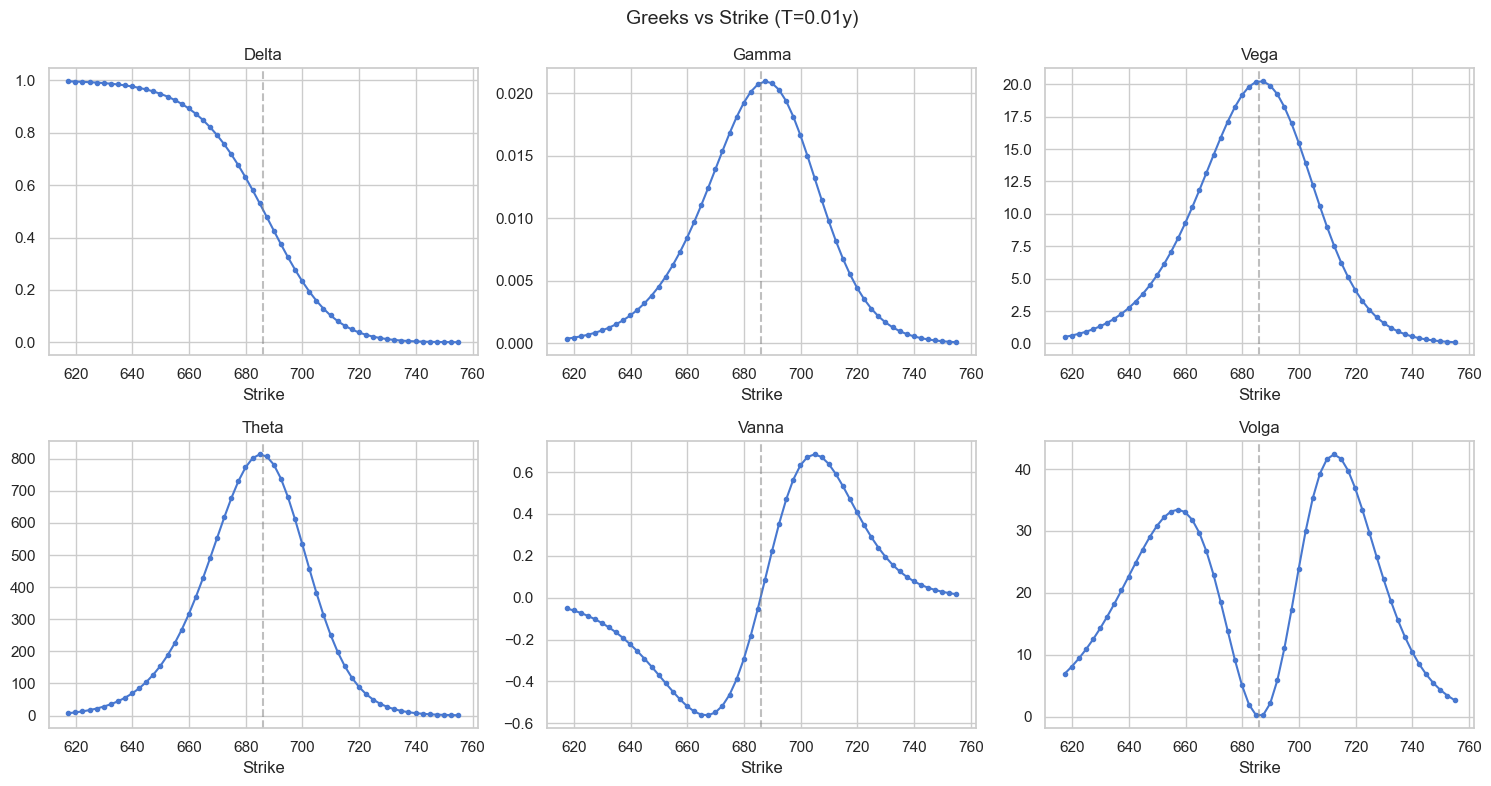

In [8]:
sample_expiry = chain.expiries()[2]
T_greeks = (sample_expiry - pd.Timestamp.now()).days / 365.25
F_greeks = forwards[sample_expiry]
r_greeks = curve.rate(T_greeks)

strikes_greeks = np.arange(spot * 0.90, spot * 1.10 + 1, 2.5)
greek_rows = []
for K_g in strikes_greeks:
    k_log = np.log(K_g / F_greeks)
    sigma_g = surface.implied_vol(k_log, T_greeks)
    g = greeks_compute(F_greeks, K_g, T_greeks, r_greeks, sigma_g, True)
    greek_rows.append({
        'strike': K_g, 'iv': sigma_g * 100,
        'delta': g.delta, 'gamma': g.gamma,
        'vega': g.vega, 'theta': g.theta,
        'vanna': g.vanna, 'volga': g.volga,
    })

df_greeks = pd.DataFrame(greek_rows)
print('Greeks for T=%.2fy (expiry %s):' % (T_greeks, sample_expiry.date()))
print(df_greeks.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ['delta', 'gamma', 'vega', 'theta', 'vanna', 'volga']):
    ax.plot(df_greeks['strike'], df_greeks[col], 'o-', markersize=3)
    ax.set_title(col.capitalize())
    ax.set_xlabel('Strike')
    ax.axvline(spot, color='gray', linestyle='--', alpha=0.5)
fig.suptitle('Greeks vs Strike (T=%.2fy)' % T_greeks, fontsize=14)
plt.tight_layout()
plt.show()

## 7. Risk Ladder (2D Full Revaluation)

Portfolio base value: $-8610.97
P&L matrix shape: (21, 21)
Max gain: $15499.81, Max loss: $3701.04


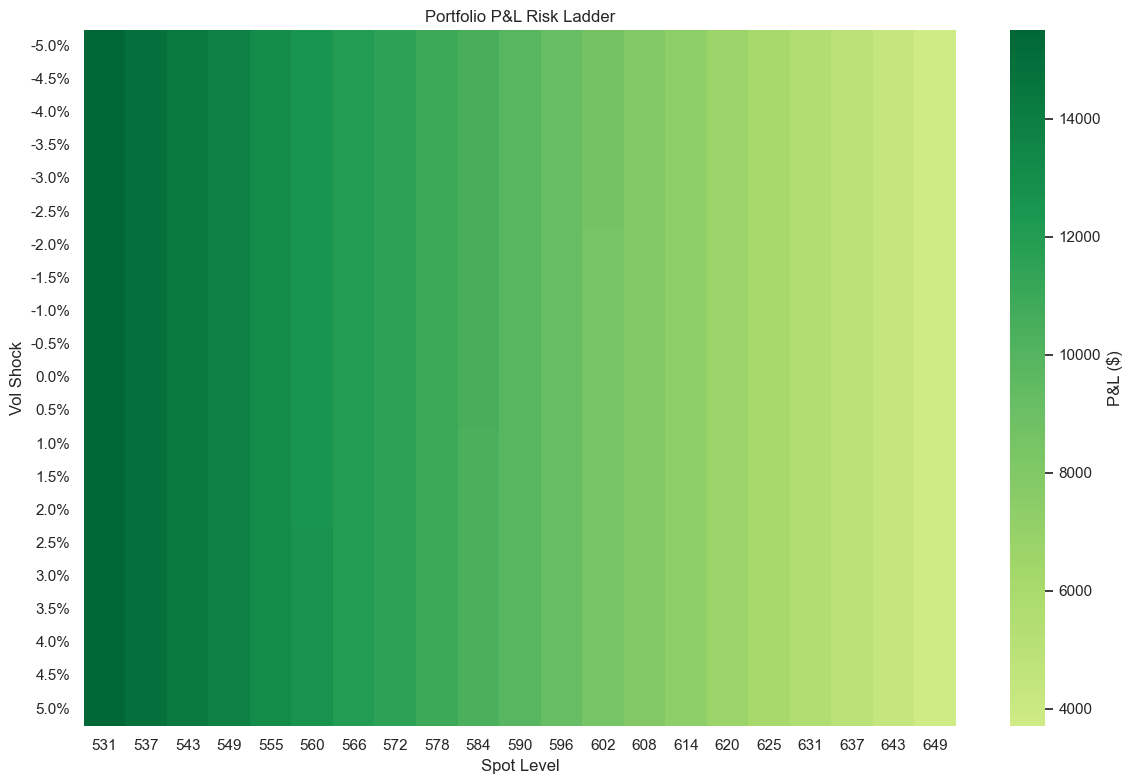

In [9]:
from python.risk.risk_ladder import compute_risk_ladder

positions = []
for K_pos, qty, is_c in [(580, 100, True), (590, -200, True), (600, 100, False)]:
    exp = chain.expiries()[2]
    T_pos = (exp - pd.Timestamp.now()).days / 365.25
    positions.append({
        'strike': float(K_pos), 'expiry_years': T_pos,
        'is_call': is_c, 'quantity': qty, 'forward': forwards[exp],
    })

avg_strike = np.mean([p['strike'] for p in positions])
spot_shocks_pct = (np.linspace(avg_strike * 0.90, avg_strike * 1.10, 21) / spot - 1.0) * 100.0
ladder = compute_risk_ladder(positions, surface, curve, spot,
                             spot_shocks_pct=spot_shocks_pct)
print('Portfolio base value: $%.2f' % ladder['base_value'])
print('P&L matrix shape: %s' % str(ladder['pnl_matrix'].shape))
print('Max gain: $%.2f, Max loss: $%.2f'
      % (ladder['pnl_matrix'].max(), ladder['pnl_matrix'].min()))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    ladder['pnl_matrix'].T,
    xticklabels=['%.0f' % s for s in ladder['spot_levels']],
    yticklabels=['%.1f%%' % (v * 100) for v in ladder['vol_shocks']],
    center=0, cmap='RdYlGn', fmt='.0f', ax=ax,
    cbar_kws={'label': 'P&L ($)'},
)
ax.set_xlabel('Spot Level')
ax.set_ylabel('Vol Shock')
ax.set_title('Portfolio P&L Risk Ladder')
plt.tight_layout()
plt.show()

## 8. Hedging Efficient Frontier

Computed 25 frontier points
Unhedged variance: 4709594.35
Best hedged variance: 0.00 (cost $12.34)


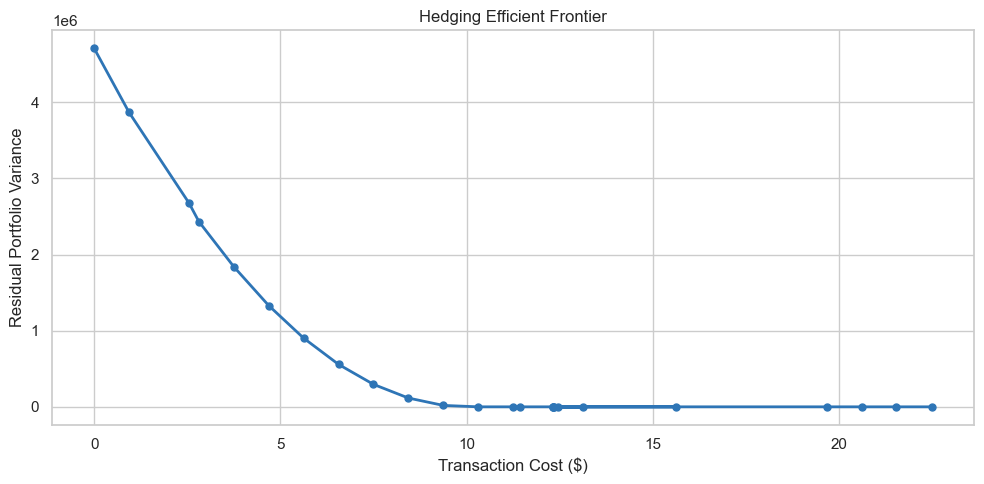

In [10]:
from python.risk.hedging import build_scenario_pnl_matrix, compute_efficient_frontier

spot_shocks = np.linspace(-5, 5, 11)
vol_shocks = np.linspace(-0.03, 0.03, 7)

# Portfolio scenario P&L
portfolio_pnl = []
for ds in spot_shocks:
    for dv in vol_shocks:
        S_new = spot * (1.0 + ds / 100.0)
        total = 0.0
        for pos in positions:
            K_h = pos['strike']
            T_h = pos['expiry_years']
            F_h = S_new / spot * pos['forward']
            k_h = np.log(K_h / F_h)
            sig_h = max(surface.implied_vol(k_h, T_h) + dv, 0.01)
            r_h = curve.rate(T_h)
            px = bs_price(F_h, K_h, T_h, r_h, sig_h, pos['is_call'])
            total += px * pos['quantity']
        portfolio_pnl.append(total)
base_portfolio = portfolio_pnl[len(portfolio_pnl) // 2]
portfolio_pnl = np.array(portfolio_pnl) - base_portfolio

# Hedge universe
hedge_universe = []
for K_hu, is_c in [(570, True), (585, True), (600, False), (610, False)]:
    exp = chain.expiries()[2]
    T_hu = (exp - pd.Timestamp.now()).days / 365.25
    hedge_universe.append({
        'strike': float(K_hu), 'expiry_years': T_hu,
        'is_call': is_c, 'forward': forwards[exp],
    })

hedge_pnl = build_scenario_pnl_matrix(
    hedge_universe, spot_shocks, vol_shocks,
    surface.implied_vol, bs_price, curve.rate, spot,
)
hedge_costs = np.array([0.10, 0.15, 0.12, 0.08])

frontier = compute_efficient_frontier(portfolio_pnl, hedge_pnl, hedge_costs, budget_steps=25)

costs_f = [f['actual_cost'] for f in frontier]
variances_f = [f['residual_variance'] for f in frontier]
print('Computed %d frontier points' % len(frontier))
print('Unhedged variance: %.2f' % variances_f[0])
print('Best hedged variance: %.2f (cost $%.2f)' % (min(variances_f), costs_f[variances_f.index(min(variances_f))]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(costs_f, variances_f, 'o-', color='#2E75B6', linewidth=2, markersize=5)
ax.set_xlabel('Transaction Cost ($)')
ax.set_ylabel('Residual Portfolio Variance')
ax.set_title('Hedging Efficient Frontier')
plt.tight_layout()
plt.show()

## 9. ETF Premium / Discount Analysis

In [11]:
from python.models.etf_premium import estimate_premium, adjust_surface_for_premium

nav = spot * 0.998  # realistic ~0.2% discount
nav_fwd = forwards[chain.expiries()[2]] * (nav / spot)
premium = estimate_premium(spot, nav, forwards[chain.expiries()[2]], nav_fwd, T_greeks)
print(premium['description'])

raw_iv = 0.18
adj_iv = adjust_surface_for_premium(raw_iv, premium['spot_premium_pct'], T_greeks)
print('Raw IV: %.2f%% -> Premium-adjusted IV: %.2f%%' % (raw_iv * 100, adj_iv * 100))

ETF trades at +0.20% to NAV (spot). Forward implies +0.20% premium at T=0.01y. Estimated premium mean-reversion: 0.0%/yr.
Raw IV: 18.00% -> Premium-adjusted IV: 17.92%


## 10. ML Warm-Start (Synthetic Demo) with Timing Comparison

The GBT model predicts SSVI parameter *deltas* from market features
(VIX, yield slope, realised vol, put-call ratio, prior params) to
warm-start the calibration optimizer.

**Arb-free guarantee: unconditionally preserved.** The GBT output
is only an initial guess — the constrained optimizer still runs to
full convergence with arb penalty enforcement.

In [12]:
from python.ml.warm_start import WarmStartModel

# Build synthetic training data from the already-calibrated surface
print('Building synthetic training set from calibrated surface ...')
train_rows = []
rng = np.random.default_rng(42)
for i in range(200):
    vix = 15.0 + rng.normal(0, 5)
    slope = 0.01 + rng.normal(0, 0.005)
    rvol_1d = 0.15 + rng.normal(0, 0.03)
    rvol_5d = 0.14 + rng.normal(0, 0.025)
    rvol_20d = 0.13 + rng.normal(0, 0.02)
    pcr = 0.8 + rng.normal(0, 0.15)
    for T_train, params_train in surface.params_by_tenor.items():
        theta_prev = params_train.theta * (1 + rng.normal(0, 0.05))
        rho_prev = np.clip(params_train.rho + rng.normal(0, 0.02), -0.99, 0.99)
        eta_prev = max(params_train.eta * (1 + rng.normal(0, 0.05)), 0.01)
        train_rows.append({
            'vix': vix, 'yield_slope_10y_2y': slope,
            'rvol_1d': rvol_1d, 'rvol_5d': rvol_5d, 'rvol_20d': rvol_20d,
            'put_call_volume_ratio': pcr,
            'prev_theta': theta_prev, 'prev_rho': rho_prev, 'prev_eta': eta_prev,
            'd_theta': params_train.theta - theta_prev,
            'd_rho': params_train.rho - rho_prev,
            'd_eta': params_train.eta - eta_prev,
        })

train_df = pd.DataFrame(train_rows)
print('Training samples: %d' % len(train_df))

ws_model = WarmStartModel(n_estimators=100, max_depth=3)
ws_model.train(train_df)
print('[OK] WarmStartModel trained')

Building synthetic training set from calibrated surface ...
Training samples: 6000
  [warm_start] Trained on 6000 samples.
[OK] WarmStartModel trained


In [14]:
from python.models.surface import _prepare_slices

# Re-calibrate with ML warm-start
features = {
    'vix': 18.0, 'yield_slope_10y_2y': 0.012,
    'rvol_1d': 0.16, 'rvol_5d': 0.15, 'rvol_20d': 0.14,
    'put_call_volume_ratio': 0.85,
}

# --- Classical (cold start, no prior surface) ---
t0 = time.perf_counter()
surface_cold = calibrate_surface(chain, forwards, curve)
cold_time = time.perf_counter() - t0

# --- ML warm-start (reuses cached slices — skips implied vol inversion) ---
t0 = time.perf_counter()
surface_ml = calibrate_surface(
    chain, forwards, curve,
    prev_surface=surface,
    warm_start_model=ws_model,
    market_features=features,
    _cached_slices=surface_cold._cached_slices,
)
ml_time = time.perf_counter() - t0


# Compare parameters
print('\nClassical vs ML-assisted parameters:')
print('%-8s  %-24s  %-24s' % ('Tenor', 'Classical (theta,rho,eta)', 'ML-warm (theta,rho,eta)'))
common_tenors = sorted(set(surface_cold.params_by_tenor.keys()) & set(surface_ml.params_by_tenor.keys()))
for T_cmp in common_tenors:
    p1 = surface_cold.params_by_tenor[T_cmp]
    p2 = surface_ml.params_by_tenor[T_cmp]
    print('%-8.3f  (%.4f, %+.4f, %.4f)  (%.4f, %+.4f, %.4f)' % (
        T_cmp,
        p1.theta, p1.rho, p1.eta,
        p2.theta, p2.rho, p2.eta,
    ))

  [surface] 45 arb violations pre-correction; re-fitting with global rho/eta.
  [surface] 45 arb violations pre-correction; re-fitting with global rho/eta.

Classical vs ML-assisted parameters:
Tenor     Classical (theta,rho,eta)  ML-warm (theta,rho,eta) 
0.019     (0.0008, -0.2999, 0.4998)  (0.0007, -0.3000, 0.4999)
0.022     (0.0007, -0.2999, 0.4998)  (0.0007, -0.3000, 0.4999)
0.025     (0.0010, -0.2999, 0.4998)  (0.0010, -0.3000, 0.4999)
0.027     (0.0012, -0.2999, 0.4998)  (0.0012, -0.3000, 0.4999)
0.030     (0.0013, -0.2999, 0.4998)  (0.0013, -0.3000, 0.4999)
0.049     (0.0007, -0.2999, 0.4998)  (0.0007, -0.3000, 0.4999)
0.068     (0.0032, -0.2999, 0.4998)  (0.0032, -0.3000, 0.4999)
0.079     (0.0028, -0.2999, 0.4998)  (0.0027, -0.3000, 0.4999)
0.085     (0.0038, -0.2999, 0.4998)  (0.0038, -0.3000, 0.4999)
0.107     (0.0045, -0.2999, 0.4998)  (0.0045, -0.3000, 0.4999)
0.126     (0.0038, -0.2999, 0.4998)  (0.0038, -0.3000, 0.4999)
0.162     (0.0071, -0.2999, 0.4998)  (0.0071, -0.30